
#  Image Captioning — InceptionV3 (Optimisé & Commenté)

Ce notebook met en place un pipeline complet **Image → Légende** avec :
- **InceptionV3** comme encodeur d'images (fine-tuning partiel)
- **Décodeur LSTM** régularisé (**Dropout + L2**)
- **Callbacks** : EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
- **Accélération** via **cache des features** et **pipeline `tf.data`**
- Visualisations : **courbe de loss**, **grille d'images** avec **captions prédites**



##  Prérequis & structure des données

Adaptez **les chemins** ci-dessous à votre machine. Exemple de structure (type MSCOCO) :

```
DATA_ROOT/
  images/
    train2014/
    val2014/
    test2014/
  annotations/
    captions_train2014.json
    captions_val2014.json
```


In [ ]:

# ▶️ Imports & préparation GPU
import os, json, random, math, pathlib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras import mixed_precision  # + mixed precision

print("TensorFlow:", tf.__version__)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU détecté ✅ — memory growth activé")
else:
    print("Aucun GPU détecté — l'entraînement sera plus lent")

# 🚀 Accélération: mixed precision + XLA
mixed_precision.set_global_policy('mixed_float16')
tf.config.optimizer.set_jit(True)
print("Policy MP:", mixed_precision.global_policy())
    
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

In [ ]:

# 📁 Chemins — A DÉFINIR selon votre machine
DATA_ROOT      = "/workspace/data/DatasetLiv3/archive/coco2014"                     # <-- MODIFIER ICI
TRAIN_IMG_DIR  = os.path.join(DATA_ROOT, "images", "train2014")
VAL_IMG_DIR    = os.path.join(DATA_ROOT, "images", "val2014")
TEST_IMG_DIR   = os.path.join(DATA_ROOT, "images", "test2014")
TRAIN_CAP_JSON = os.path.join(DATA_ROOT, "annotations", "captions_train2014.json")
VAL_CAP_JSON   = os.path.join(DATA_ROOT, "annotations", "captions_val2014.json")

FEATURES_DIR   = os.path.join(DATA_ROOT, "features_inceptionV3")
os.makedirs(FEATURES_DIR, exist_ok=True)

# 🔧 Hyperparamètres
IMAGE_SIZE = (299, 299)
VOCAB_SIZE = 10000
MAX_LEN    = 25
EMBED_DIM  = 256
DEC_HID    = 512
DROPOUT_P  = 0.5
L2_REG     = 1e-4
BATCH_SIZE = 4
EPOCHS     = 30  # point de départ; EarlyStopping arrêtera plus tôt si nécessaire
LR         = 1e-4
FINE_TUNE_LAST_N = 40

START_TOKEN = "<start>"
END_TOKEN   = "<end>"
OOV_TOKEN   = "<unk>"

# ⚡ Mode rapide (réduit le temps d'entraînement)
FAST_TRAIN = True
FAST_CFG = {
  "EPOCHS": 8,
  "MAX_LEN": 20,
  "BATCH_SIZE": 16,
  "EMBED_DIM": 192,
  "DEC_HID": 384,
  "VOCAB_SIZE": 6000,
  "TRAIN_MAX_IMAGES": 10000,   # sous-échantillonnage images
  "VAL_MAX_IMAGES": 2000,
  "CAPS_PER_IMAGE": 1,        # 1 légende par image
  "TRAIN_STEPS": 1500,        # limite de pas par epoch
  "VAL_STEPS": 200
}
if FAST_TRAIN:
    EPOCHS = FAST_CFG["EPOCHS"]
    MAX_LEN = FAST_CFG["MAX_LEN"]
    BATCH_SIZE = FAST_CFG["BATCH_SIZE"]
    EMBED_DIM = FAST_CFG["EMBED_DIM"]
    DEC_HID = FAST_CFG["DEC_HID"]
    VOCAB_SIZE = min(VOCAB_SIZE, FAST_CFG["VOCAB_SIZE"])

# 🎯 Entraînement end-to-end (désactive le cache de features et intègre le CNN au modèle)
END_TO_END = True  # passez à True pour fine-tuner InceptionV3

for p in [TRAIN_IMG_DIR, VAL_IMG_DIR, TEST_IMG_DIR, TRAIN_CAP_JSON, VAL_CAP_JSON]:
    print("→", p)

In [ ]:
# 🛟 Récupération après redémarrage du kernel (ckpt_path, tokenizer, index2word)
def _tokenizer_from_json_file(path):
    try:
        from tensorflow.keras.preprocessing.text import tokenizer_from_json
    except Exception:
        from keras.preprocessing.text import tokenizer_from_json
    with open(path, "r", encoding="utf-8") as f:
        return tokenizer_from_json(f.read())

def ensure_runtime_artifacts():
    global ckpt_path, tok, index2word, EFFECTIVE_VOCAB_SIZE
    # ckpt
    if 'ckpt_path' not in globals():
        ckpt_path = os.path.join(FEATURES_DIR, "best_caption_model.keras")
    # tokenizer
    if 'tok' not in globals():
        tok_path = os.path.join(FEATURES_DIR, "tokenizer.json")
        if os.path.isfile(tok_path):
            tok_local = _tokenizer_from_json_file(tok_path)
            tok = tok_local
        else:
            print("ℹ️ tokenizer.json introuvable — il sera créé lors du fit.")
    # index2word
    if 'tok' in globals() and 'index2word' not in globals():
        eff = None
        if 'EFFECTIVE_VOCAB_SIZE' in globals():
            eff = int(EFFECTIVE_VOCAB_SIZE)
        else:
            eff = len(getattr(tok, 'word_index', {})) + 1
            EFFECTIVE_VOCAB_SIZE = eff
        index2word = {i: w for w, i in getattr(tok, 'word_index', {}).items() if i < eff}
        index2word[0] = "<pad>"
    print("✔️ ckpt_path:", ckpt_path)
    if 'tok' in globals():
        print("✔️ tokenizer chargé (vocab ≈)", len(getattr(tok, 'word_index', {})))

def get_token_id(token: str, default: int | None = None):
    if 'tok' not in globals():
        return default
    wi = tok.word_index
    return wi.get(token, wi.get(token.lower(), default))

def get_start_end_ids():
    sid = get_token_id(START_TOKEN, 1)
    eid = get_token_id(END_TOKEN, None)
    return sid, eid

ensure_runtime_artifacts()


##  Chargement des captions & Tokenizer
On lit les fichiers **COCO captions** et on construit un tokenizer **Keras** avec `<start>`, `<end>`, `<unk>`.


In [ ]:

def load_coco_captions(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    imgs = {img["id"]: img["file_name"] for img in data["images"]}
    anns = data["annotations"]
    image_to_caps = {}
    for ann in anns:
        fname = imgs[ann["image_id"]]
        image_to_caps.setdefault(fname, []).append(ann["caption"].strip())
    return image_to_caps

train_caps = load_coco_captions(TRAIN_CAP_JSON)
val_caps   = load_coco_captions(VAL_CAP_JSON)
print("#images train:", len(train_caps), " | #images val:", len(val_caps))

# Sous-échantillonnage pour mode rapide
def limit_dataset(caps_dict, max_images=None, caps_per_image=None):
    keys = list(caps_dict.keys())
    random.shuffle(keys)
    if max_images is not None:
        keys = keys[:max_images]
    out = {}
    for k in keys:
        caps = caps_dict[k]
        if caps_per_image is not None:
            caps = caps[:caps_per_image]
        out[k] = caps
    return out

if 'FAST_TRAIN' in globals() and FAST_TRAIN:
    train_caps = limit_dataset(train_caps, FAST_CFG["TRAIN_MAX_IMAGES"], FAST_CFG["CAPS_PER_IMAGE"])
    val_caps   = limit_dataset(val_caps,   FAST_CFG["VAL_MAX_IMAGES"],   1)
    print("(FAST) #images train:", len(train_caps), " | #images val:", len(val_caps))

# Texte enrichi avec tokens spéciaux
all_caps = [f"{START_TOKEN} {c} {END_TOKEN}" for caps in train_caps.values() for c in caps]

# Tokenizer — on fit sans limite puis on tronque via EFFECTIVE_VOCAB_SIZE
tok = keras.preprocessing.text.Tokenizer(
    num_words=None,
    oov_token=OOV_TOKEN,
    filters='"#$%&()*+.,-/:;=?@[\\]^_`{|}~\t\n',
    lower=True
)
tok.fit_on_texts(all_caps)

# S'assurer que les tokens spéciaux sont couverts par le vocab effectif
start_id = tok.word_index.get(START_TOKEN)
end_id   = tok.word_index.get(END_TOKEN)
unk_id   = tok.word_index.get(OOV_TOKEN)
EFFECTIVE_VOCAB_SIZE = min(VOCAB_SIZE, len(tok.word_index) + 1)
for sid in [start_id, end_id, unk_id]:
    if sid is not None and sid + 1 > EFFECTIVE_VOCAB_SIZE:
        EFFECTIVE_VOCAB_SIZE = sid + 1

# Table de décodage (id -> mot) limitée au vocab effectif
index2word = {i: w for w, i in tok.word_index.items() if i < EFFECTIVE_VOCAB_SIZE}
index2word[0] = "<pad>"
print("Vocab effectif:", EFFECTIVE_VOCAB_SIZE)

# Sauvegarde du tokenizer et du mapping pour l'inférence
tok_json_path      = os.path.join(FEATURES_DIR, "tokenizer.json")
index2word_json    = os.path.join(FEATURES_DIR, "index2word.json")
with open(tok_json_path, "w", encoding="utf-8") as f:
    f.write(tok.to_json())
with open(index2word_json, "w", encoding="utf-8") as f:
    json.dump(index2word, f, ensure_ascii=False)
print("✅ Tokenizer et index2word sauvegardés.")


##  Encodeur d'images : InceptionV3 (fine‑tuning partiel)
On extrait des **features 2048** par **GlobalAveragePooling** et on **dégèle** les **N dernières couches**.
On **cache** ensuite ces features sur disque pour accélérer l'entraînement.


In [5]:
# 🧠 InceptionV3 Backbone — Optimisé (Batch + Parallel Loading)
import concurrent.futures
from tqdm import tqdm

# Charger le modèle InceptionV3 (pré-entraîné sur ImageNet)
base_cnn = keras.applications.InceptionV3(
    include_top=False,
    weights='imagenet',
    input_shape=IMAGE_SIZE + (3,)
)
x = layers.GlobalAveragePooling2D()(base_cnn.output)
image_encoder = keras.Model(base_cnn.input, x, name="inceptionv3_encoder")

print("✅ Encodeur initialisé — sortie :", image_encoder.output_shape)

# --- Fine-tuning partiel ---
for layer in base_cnn.layers[:-FINE_TUNE_LAST_N]:
    layer.trainable = False
for layer in base_cnn.layers[-FINE_TUNE_LAST_N:]:
    layer.trainable = True
print(f"🔧 Fine-tuning activé sur les {FINE_TUNE_LAST_N} dernières couches.")

# --- Prétraitement d'image ---
def preprocess_img(path):
    """Charge et prépare une image pour InceptionV3."""
    img = Image.open(path).convert("RGB").resize(IMAGE_SIZE)
    arr = np.array(img).astype(np.float32)
    return keras.applications.inception_v3.preprocess_input(arr)

# --- Cache des features (désactivé en mode end-to-end) ---
def cache_features(img_dir, out_path, batch_size=32, max_workers=8):
    """
    Extrait et sauvegarde les features InceptionV3 pour toutes les images d'un dossier.
    Utilise traitement par lot + lecture parallèle pour accélérer le processus.
    Les features sont stockées en float16 pour économiser de l'espace.
    """
    files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    n = len(files)
    print(f"📁 Extraction des features sur {n} images depuis {img_dir} ...")

    features = {}

    # Lecture des images en parallèle (CPU)
    def load_batch(batch_files):
        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
            imgs = list(ex.map(lambda f: preprocess_img(os.path.join(img_dir, f)), batch_files))
        return np.stack(imgs, axis=0)  # (B, 299, 299, 3)

    # Boucle sur les batches
    for i in tqdm(range(0, n, batch_size), desc="Extraction en cours", ncols=90):
        batch_files = files[i:i+batch_size]
        batch_imgs = load_batch(batch_files)

        # Prédiction en un seul passage GPU (plus rapide)
        batch_feats = image_encoder.predict(batch_imgs, verbose=0)

        # Sauvegarde dans le dict
        for fname, feat in zip(batch_files, batch_feats):
            features[fname] = feat.astype(np.float16)

    # Sauvegarde finale
    np.save(out_path, features)
    print(f"✅ Features sauvegardées : {out_path} ({n} images)")

# --- Exécution du cache ---
train_feat_path = os.path.join(FEATURES_DIR, "train_features_incv3.npy")
val_feat_path   = os.path.join(FEATURES_DIR, "val_features_incv3.npy")

if not os.path.exists(train_feat_path):
    cache_features(TRAIN_IMG_DIR, train_feat_path, batch_size=32)
else:
    print("✅ Cache train déjà présent :", train_feat_path)

if not os.path.exists(val_feat_path):
    cache_features(VAL_IMG_DIR, val_feat_path, batch_size=32)
else:
    print("✅ Cache val déjà présent :", val_feat_path)

# --- Chargement final ---
train_feats = np.load(train_feat_path, allow_pickle=True).item()
val_feats   = np.load(val_feat_path, allow_pickle=True).item()
print(f"📊 Train features : {len(train_feats)} | Val features : {len(val_feats)}")


✅ Encodeur initialisé — sortie : (None, 2048)
🔧 Fine-tuning activé sur les 40 dernières couches.
✅ Cache train déjà présent : /workspace/data/DatasetLiv3/archive/coco2014/features_inceptionV3/train_features_incv3.npy
✅ Cache val déjà présent : /workspace/data/DatasetLiv3/archive/coco2014/features_inceptionV3/val_features_incv3.npy
📊 Train features : 82783 | Val features : 2026
📊 Train features : 82783 | Val features : 2026



##  Construction des exemples (features, séquences)
On prépare `(feature, input_seq) -> next_token` pour **teacher forcing**.


In [6]:

def caps_to_sequences(caps, tokenizer, max_len):
    txts = [f"{START_TOKEN} {c} {END_TOKEN}" for c in caps]
    seqs = tokenizer.texts_to_sequences(txts)
    return keras.preprocessing.sequence.pad_sequences(seqs, maxlen=max_len, padding='post')

def build_examples(features_dict, caps_dict, tokenizer, max_len):
    F, X, Y = [], [], []
    for fname, caps in caps_dict.items():
        if fname not in features_dict:
            continue
        seqs = caps_to_sequences(caps, tokenizer, max_len)
        for s in seqs:
            F.append(features_dict[fname])
            X.append(s[:-1])  # input
            Y.append(s[1:])   # target décalé
    return np.array(F), np.array(X), np.array(Y)

if not END_TO_END:
    XtrF, Xtr, Ytr = build_examples(train_feats, train_caps, tok, MAX_LEN)
    XvaF, Xva, Yva = build_examples(val_feats,   val_caps,   tok, MAX_LEN)
    print("Train:", XtrF.shape, Xtr.shape, Ytr.shape)
    print("Val  :", XvaF.shape, Xva.shape, Yva.shape)
else:
    print("End-to-end: les jeux sont construits via tf.data depuis les images.")

End-to-end: les jeux sont construits via tf.data depuis les images.



##  Pipeline `tf.data`


In [7]:
# 🚀 Pipeline tf.data — Séquence complète
AUTOTUNE = tf.data.AUTOTUNE

def generator_sequence(features_dict, caps_dict):
    """Génère (feature, input_seq) -> y_seq (séquence décalée)"""
    for fname, caps in caps_dict.items():
        if fname not in features_dict:
            continue
        feat = np.asarray(features_dict[fname]).astype(np.float32)
        seqs = caps_to_sequences(caps, tok, MAX_LEN)
        for s in seqs:
            x_seq = s[:-1].astype(np.int32)
            y_seq = s[1:].astype(np.int32)
            yield (feat, x_seq), y_seq

def generator_image_sequence(img_dir, caps_dict):
    """End-to-end: (image, input_seq) -> y_seq"""
    for fname, caps in caps_dict.items():
        path = os.path.join(img_dir, fname)
        if not os.path.isfile(path):
            continue
        img = preprocess_img(path).astype(np.float32)  # (299,299,3) prétraité
        seqs = caps_to_sequences(caps, tok, MAX_LEN)
        for s in seqs:
            x_seq = s[:-1].astype(np.int32)
            y_seq = s[1:].astype(np.int32)
            yield (img, x_seq), y_seq

if not END_TO_END:
    train_ds = tf.data.Dataset.from_generator(
        lambda: generator_sequence(train_feats, train_caps),
        output_signature=(
            (tf.TensorSpec(shape=(2048,), dtype=tf.float32),
             tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)),
            tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)
        )
    ).shuffle(2048, reshuffle_each_iteration=True).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_generator(
        lambda: generator_sequence(val_feats, val_caps),
        output_signature=(
            (tf.TensorSpec(shape=(2048,), dtype=tf.float32),
             tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)),
            tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)
        )
    ).batch(BATCH_SIZE).prefetch(AUTOTUNE)
else:
    train_ds = tf.data.Dataset.from_generator(
        lambda: generator_image_sequence(TRAIN_IMG_DIR, train_caps),
        output_signature=(
            (tf.TensorSpec(shape=IMAGE_SIZE + (3,), dtype=tf.float32),
             tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)),
            tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)
        )
    ).shuffle(2048, reshuffle_each_iteration=True).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_generator(
        lambda: generator_image_sequence(VAL_IMG_DIR, val_caps),
        output_signature=(
            (tf.TensorSpec(shape=IMAGE_SIZE + (3,), dtype=tf.float32),
             tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)),
            tf.TensorSpec(shape=(MAX_LEN-1,), dtype=tf.int32)
        )
    ).batch(BATCH_SIZE).prefetch(AUTOTUNE)

if 'FAST_TRAIN' in globals() and FAST_TRAIN:
    train_ds = train_ds.take(FAST_CFG["TRAIN_STEPS"])
    val_ds   = val_ds.take(FAST_CFG["VAL_STEPS"])

print("✅ Pipeline prêt (END_TO_END=", END_TO_END, ")")

✅ Pipeline prêt (END_TO_END= True )



##  Décodeur LSTM (Dropout + L2)


In [8]:

# Taille de vocabulaire stable
vocab_size = int(EFFECTIVE_VOCAB_SIZE)

if not END_TO_END:
    inp_img = layers.Input(shape=(2048,), name="img_feat")
    # Projection features -> seq
    x_img = layers.Dense(DEC_HID, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(inp_img)
    x_img = layers.Dropout(DROPOUT_P)(x_img)
    x_img_seq = layers.RepeatVector(MAX_LEN - 1)(x_img)
else:
    inp_img = layers.Input(shape=IMAGE_SIZE + (3,), name="img_raw")  # prétraité dans tf.data
    cnn_feats = base_cnn(inp_img)                        # (B, H, W, C)
    gap_feats = layers.GlobalAveragePooling2D()(cnn_feats) # (B, 2048)
    x_img = layers.Dense(DEC_HID, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(gap_feats)
    x_img = layers.Dropout(DROPOUT_P)(x_img)
    x_img_seq = layers.RepeatVector(MAX_LEN - 1)(x_img)

inp_seq = layers.Input(shape=(MAX_LEN-1,), name="seq_in")
emb   = layers.Embedding(vocab_size, EMBED_DIM, mask_zero=True, name="embedding")(inp_seq)
x_txt = layers.LSTM(DEC_HID, return_sequences=True, name="decoder_lstm")(emb)
x_txt = layers.Dropout(DROPOUT_P)(x_txt)

x = layers.Concatenate()([x_img_seq, x_txt])
x = layers.Dense(DEC_HID, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(x)
x = layers.Dropout(DROPOUT_P)(x)
out = layers.Dense(vocab_size, activation='softmax', name="softmax_out", dtype='float32')(x)

decoder = keras.Model([inp_img, inp_seq], out, name="caption_decoder")
decoder.summary()

opt = keras.optimizers.Adam(learning_rate=LR, clipnorm=5.0)
decoder.compile(optimizer=opt, loss="sparse_categorical_crossentropy")

Model: "caption_decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_raw             │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_v3        │ (None, 8, 8,      │ 21,802,784 │ img_raw[0][0]     │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ inception_v3[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_in (InputLayer) │ (None, 19)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 384)       │    786,816 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 19, 192)   │    888,192 │ seq_in[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 19)        │          0 │ seq_in[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 19, 384)   │    886,272 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 19, 384)   │          0 │ dropout[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 19, 384)   │          0 │ decoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 19, 768)   │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 19, 384)   │    295,296 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 19, 384)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_out (Dense) │ (None, 19, 4626)  │  1,781,010 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,440,370 (100.86 MB)

 Trainable params: 10,711,314 (40.86 MB)

 Non-trainable params: 15,729,056 (60.00 MB)


##  Entraînement avec callbacks


In [9]:
# ✅ Chemin du checkpoint (meilleur modèle)
ckpt_path = os.path.join(FEATURES_DIR, "best_caption_model.keras")

# ✅ Callbacks Keras
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,  # plus agressif pour arrêter plus tôt
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=ckpt_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,  # accélère la baisse du LR
    verbose=1,
    min_lr=1e-6
)

csv_logger = keras.callbacks.CSVLogger(os.path.join(FEATURES_DIR, "training_log.csv"))

# 🚀 Entraînement
history = decoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr, csv_logger],
    verbose=1
)

print("✅ Meilleur modèle sauvegardé →", ckpt_path)

# 📦 Sauvegardes complémentaires
final_model_path = os.path.join(FEATURES_DIR, "final_caption_model.keras")
decoder.save(final_model_path)
with open(os.path.join(FEATURES_DIR, "history.json"), "w", encoding="utf-8") as f:
    json.dump(history.history, f)
print("✅ Modèle final et historique sauvegardés.")
# 📈 Visualisation de l'historique d'entraînement

Epoch 1/8


2025-10-21 17:59:06.309591: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f7c64004920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-21 17:59:06.309627: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-21 17:59:06.328232: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90800
I0000 00:00:1761069546.377733   14940 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-10-21 17:59:21.601995: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1024 of 2048
2025-10-21 17:59:21.601995: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1024 of 2048
2025-10-21 17:59:34.457443: I

    625/Unknown 147s 136ms/step - loss: 4.6592

2025-10-21 18:01:29.326298: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-10-21 18:01:29.326369: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 12845316221100304610
2025-10-21 18:01:29.326380: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert/data_0/_8]]
2025-10-21 18:01:29.326397: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8302252953152159767
2025-10-21 18:01:29.326401: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5891789490927535110
2025-10-21 18:01:29.326409: I tens


Epoch 1: val_loss improved from None to 3.15190, saving model to /workspace/data/DatasetLiv3/archive/coco2014/features_inceptionV3/best_caption_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 196ms/step - loss: 3.7376 - val_loss: 3.1519 - learning_rate: 1.0000e-04
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 196ms/step - loss: 3.7376 - val_loss: 3.1519 - learning_rate: 1.0000e-04
Epoch 2/8


...

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 2.2330

2025-10-21 18:17:41.174450: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8302252953152159767
2025-10-21 18:17:41.174478: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9022585885371142205
2025-10-21 18:17:41.174485: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 570888730931094045
2025-10-21 18:17:41.174487: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 5820547985763601615
2025-10-21 18:17:41.174502: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2399725056535474446
2025-10-21 18:17:41.174505: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5891789490927535110



Epoch 8: val_loss improved from 2.37273 to 2.34945, saving model to /workspace/data/DatasetLiv3/archive/coco2014/features_inceptionV3/best_caption_model.keras


2025-10-21 18:18:02.964955: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 10302595258990405914
2025-10-21 18:18:02.965047: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 16714471878533318096
2025-10-21 18:18:02.965052: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 5233104055511578175
2025-10-21 18:18:02.965055: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 3600854086815629205
2025-10-21 18:18:02.965060: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[StatefulPartitionedCall/Shape/_20]]


625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 179ms/step - loss: 2.2045 - val_loss: 2.3494 - learning_rate: 1.0000e-04
✅ Meilleur modèle sauvegardé → /workspace/data/DatasetLiv3/archive/coco2014/features_inceptionV3/best_caption_model.keras
✅ Meilleur modèle sauvegardé → /workspace/data/DatasetLiv3/archive/coco2014/features_inceptionV3/best_caption_model.keras
✅ Modèle final et historique sauvegardés.
✅ Modèle final et historique sauvegardés.



##  Courbe de perte


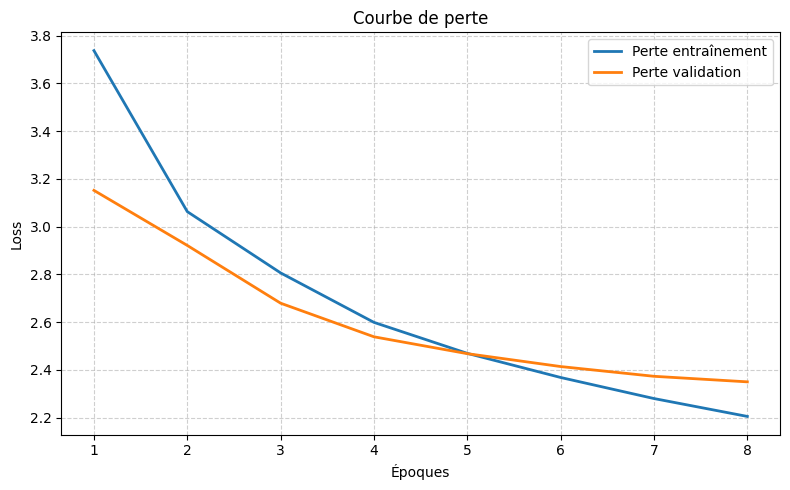

Courbe sauvegardée → /workspace/data/DatasetLiv3/archive/coco2014/features_inceptionV3/loss_curve.png


In [10]:

# Chargement résilient de l'historique (kernel redémarré)
history_dict = None
if 'history' in globals():
    history_dict = history.history
else:
    try:
        with open(os.path.join(FEATURES_DIR, "history.json"), "r", encoding="utf-8") as f:
            history_dict = json.load(f)
            print("ℹ️ history.json chargé depuis le disque.")
    except Exception as e:
        print("⚠️ Impossible de charger l'historique:", e)
        history_dict = {}

train_loss = (history_dict or {}).get('loss', [])
val_loss   = (history_dict or {}).get('val_loss', [])
if not train_loss and not val_loss:
    print("Aucun historique disponible — lancez l'entraînement d'abord.")
else:
    epochs = range(1, max(len(train_loss), len(val_loss)) + 1)
    plt.figure(figsize=(8,5))
    if train_loss: plt.plot(epochs, train_loss, label='Perte entraînement', linewidth=2)
    if val_loss:   plt.plot(epochs, val_loss,   label='Perte validation', linewidth=2)
    plt.title("Courbe de perte")
    plt.xlabel("Époques")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plot_path = os.path.join(FEATURES_DIR, "loss_curve.png")
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print("Courbe sauvegardée →", plot_path)


##  Inférence (greedy) + Grille d'images


In [11]:

def decode_tokens(ids, index2word, start=START_TOKEN, end=END_TOKEN):
    words = []
    for i in ids:
        if i == 0:
            continue
        w = index2word.get(i, OOV_TOKEN)
        if w in [start, end]:
            continue
        words.append(w)
    return " ".join(words)

def generate_caption_from_feature(feat_vec, max_len=MAX_LEN):
    sid, eid = get_start_end_ids() if 'get_start_end_ids' in globals() else (tok.word_index.get(START_TOKEN, 1), tok.word_index.get(END_TOKEN, None))
    seq = [sid]
    for _ in range(max_len-1):
        inp = keras.preprocessing.sequence.pad_sequences([seq], maxlen=MAX_LEN-1, padding='post')
        preds = decoder.predict([feat_vec[np.newaxis, :].astype(np.float32), inp], verbose=0)
        last_pos = min(len(seq)-1, MAX_LEN-2)  # index dans [0..T-1]
        prob = preds[0, last_pos]
        next_id = int(np.argmax(prob))
        if (eid is not None and next_id == eid) or next_id == 0:
            break
        seq.append(next_id)
    return decode_tokens(seq, index2word)

def generate_caption_from_path(path, max_len=MAX_LEN):
    sid, eid = get_start_end_ids() if 'get_start_end_ids' in globals() else (tok.word_index.get(START_TOKEN, 1), tok.word_index.get(END_TOKEN, None))
    seq = [sid]
    for _ in range(max_len-1):
        inp = keras.preprocessing.sequence.pad_sequences([seq], maxlen=MAX_LEN-1, padding='post')
        img = preprocess_img(path).astype(np.float32)
        preds = decoder.predict([img[np.newaxis, ...], inp], verbose=0)
        last_pos = min(len(seq)-1, MAX_LEN-2)
        prob = preds[0, last_pos]
        next_id = int(np.argmax(prob))
        if (eid is not None and next_id == eid) or next_id == 0:
            break
        seq.append(next_id)
    return decode_tokens(seq, index2word)

# Cache test uniquement si non end-to-end
test_feat_path = os.path.join(FEATURES_DIR, "test_features_incv3.npy")
if not END_TO_END and os.path.isdir(TEST_IMG_DIR):
    if not os.path.exists(test_feat_path):
        d = {}
        files = [f for f in os.listdir(TEST_IMG_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for i, fname in enumerate(files, 1):
            p = os.path.join(TEST_IMG_DIR, fname)
            arr = preprocess_img(p)
            vec = image_encoder.predict(arr[np.newaxis, ...], verbose=0).squeeze(0)
            d[fname] = vec.astype(np.float16)
            if i % 500 == 0: print(f"  Test feats: {i}/{len(files)}")
        np.save(test_feat_path, d)
    test_feats = np.load(test_feat_path, allow_pickle=True).item()
else:
    test_feats = {}
    if not os.path.isdir(TEST_IMG_DIR):
        print("TEST_IMG_DIR introuvable — fallback sur val2014")

2025-10-21 18:18:12.032863: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 296 bytes spill stores, 296 bytes spill loads



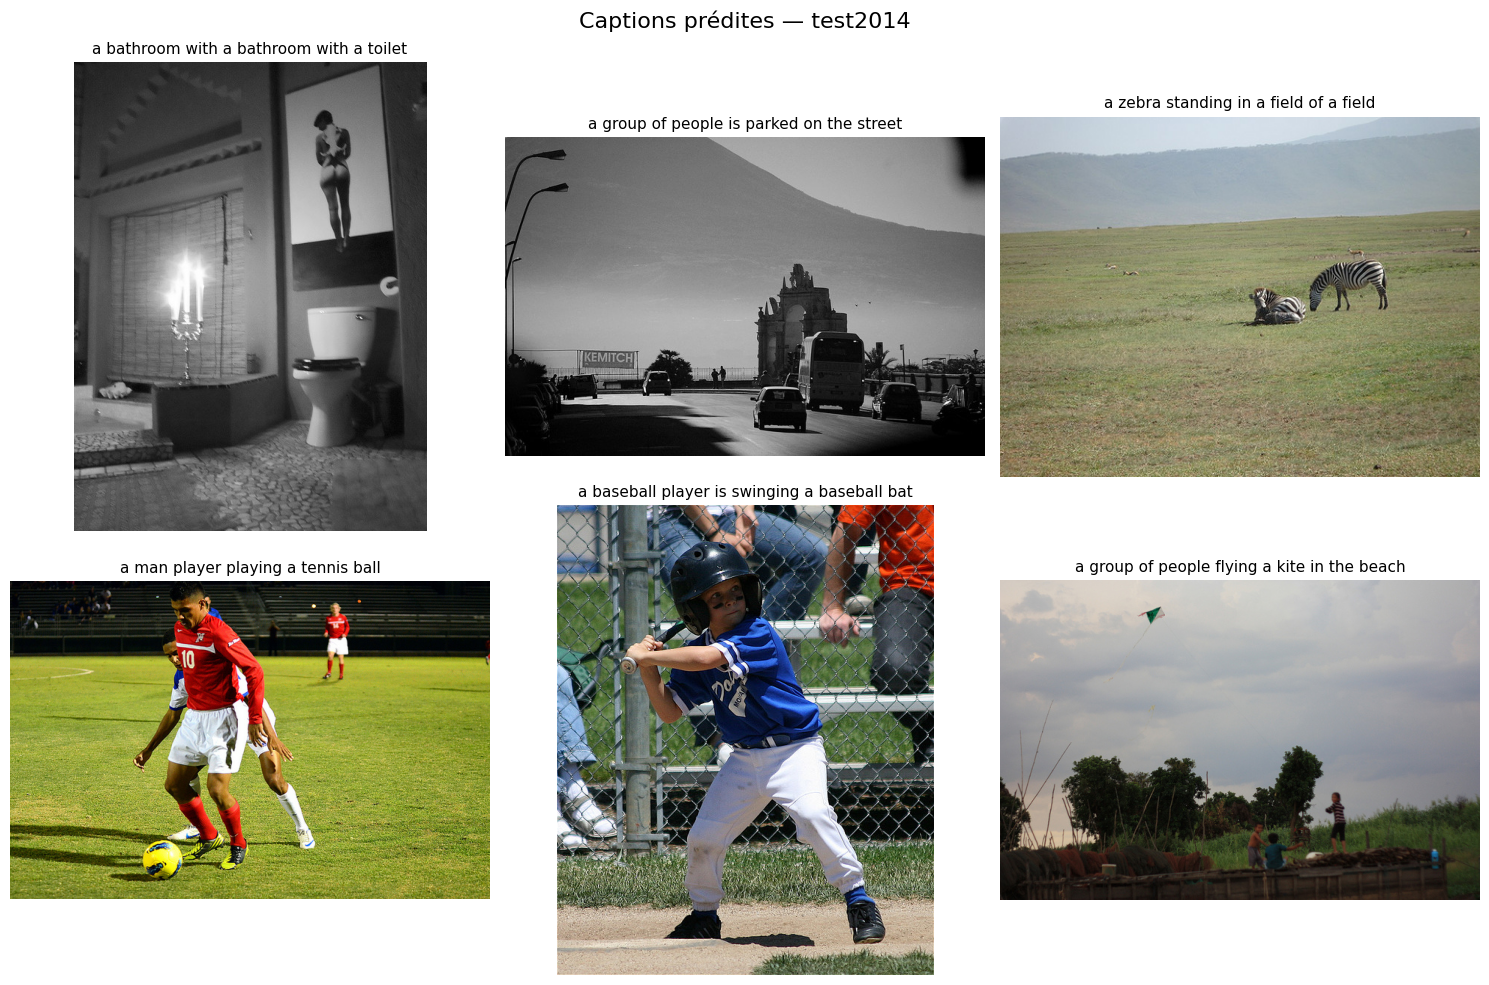

Grille sauvegardée → /workspace/data/DatasetLiv3/archive/coco2014/features_inceptionV3/grid_predictions.png


In [12]:

def show_predictions_grid(img_dir, features_cache, num_images=6, cols=3, title="Captions prédites"):
    files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if not files:
        print("Aucune image dans", img_dir); return
    sample = random.sample(files, min(num_images, len(files)))
    rows = int(np.ceil(len(sample)/cols))
    plt.figure(figsize=(15, 5*rows))
    for i, fname in enumerate(sample):
        path = os.path.join(img_dir, fname)
        if END_TO_END:
            cap = generate_caption_from_path(path)
        else:
            if fname in features_cache:
                feat = np.asarray(features_cache[fname]).astype(np.float32)
            else:
                arr = preprocess_img(path)
                feat = image_encoder.predict(arr[np.newaxis, ...], verbose=0).squeeze(0).astype(np.float32)
            cap = generate_caption_from_feature(feat)
        img = Image.open(path)
        plt.subplot(rows, cols, i+1)
        plt.imshow(img); plt.axis("off")
        plt.title(cap, fontsize=11, wrap=True)
    plt.suptitle(title + f" — {os.path.basename(img_dir)}", fontsize=16)
    plt.tight_layout()
    grid_path = os.path.join(FEATURES_DIR, "grid_predictions.png")
    plt.savefig(grid_path, dpi=150)
    plt.show()
    print("Grille sauvegardée →", grid_path)

if os.path.isdir(TEST_IMG_DIR):
    show_predictions_grid(TEST_IMG_DIR, test_feats, num_images=6, cols=3)
else:
    show_predictions_grid(VAL_IMG_DIR, {}, num_images=6, cols=3)

## Combien d'epochs utiliser ?

- Départ recommandé: `EPOCHS=30` avec `EarlyStopping(patience=3)` et `ReduceLROnPlateau`.
- Sur COCO complet, l' arrêt effectif survient souvent entre 8 et 20 epochs.
- Petit sous-ensemble: essayez 10–15 epochs.
- Pour des résultats supérieurs: augmentez la capacité/beam search et surveillez l'overfitting; montez jusqu'à ~40 si la validation continue d'améliorer.
- Remarque: avec le cache de features, l'encodeur InceptionV3 n'est pas affiné. Pour du vrai fine-tuning, entraînez l'encodeur end‑to‑end sans cache.